# Project Choice 1: Multimodal Fake News Classification

**Group Members:**  
- Abdullah Naveed  
- Ahmed Jamil  

### Part 1: Data Exploration & Literature Review
In this part, we will explore the Fakeddit dataset by examining its structure, features, and distributions.  
We will also review relevant literature to understand prior approaches for multimodal fake news detection.  
This step will give us the foundation to design and implement effective text–image classification models in later stages.

In [86]:
import os
import io
import pandas as pd
import numpy as np
from urllib import request
from tqdm import trange
from pathlib import Path
import matplotlib.pyplot as plt
from urllib import request
from PIL import Image

## Loading the Dataset

In [22]:
############################### Define dataset paths
BASE_DATA_DIR = Path("../..") / "project_dataset" / "fakeddit_data" / "multimodal_only_samples"

In [23]:
############################ Function to load dataset
def load_dataset(filename: str, sep="\t") -> pd.DataFrame:
    file_path = BASE_DATA_DIR / filename
    if not file_path.exists():
        raise FileNotFoundError(f"{file_path} not found. Please check dataset setup.")
    return pd.read_csv(file_path, sep=sep)

In [24]:
############################### Load train, validation, and test datasets
train_df = load_dataset("multimodal_train.tsv")
val_df   = load_dataset("multimodal_validate.tsv")
test_df  = load_dataset("multimodal_test_public.tsv")

## Some basic info/stats about datasets

In [25]:
############################### Print dataset stats
print("Train dataset shape:", train_df.shape)
print("Validation dataset shape:", val_df.shape)
print("Test dataset shape:", test_df.shape)

print("\nColumn names in train dataset:")
print(train_df.columns.tolist())

print("\nData types in train dataset:")
print(train_df.dtypes)

Train dataset shape: (564000, 16)
Validation dataset shape: (59342, 16)
Test dataset shape: (59319, 16)

Column names in train dataset:
['author', 'clean_title', 'created_utc', 'domain', 'hasImage', 'id', 'image_url', 'linked_submission_id', 'num_comments', 'score', 'subreddit', 'title', 'upvote_ratio', '2_way_label', '3_way_label', '6_way_label']

Data types in train dataset:
author                   object
clean_title              object
created_utc             float64
domain                   object
hasImage                   bool
id                       object
image_url                object
linked_submission_id     object
num_comments            float64
score                     int64
subreddit                object
title                    object
upvote_ratio            float64
2_way_label               int64
3_way_label               int64
6_way_label               int64
dtype: object


In [26]:
############################### Preview first 10 rows of train dataset
print("\nFirst 5 rows of train dataset:")
train_df.head(5)


First 5 rows of train dataset:


,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,subreddit,title,upvote_ratio,2_way_label,3_way_label,6_way_label
0,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,mildlyinteresting,My Walgreens offbrand Mucinex was engraved wit...,0.84,1,0,0
1,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,pareidolia,This concerned sink with a tiny hat,0.99,0,2,2
2,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,neutralnews,Hackers leak emails from UAE ambassador to US,0.92,1,0,0
3,NaN,puppy taking in the view,1.471341e+09,i.imgur.com,True,4xypkv,https://external-preview.redd.it/HLtVNhTR6wtYt...,NaN,26.0,250,photoshopbattles,PsBattle: Puppy taking in the view,0.95,1,0,0
4,3rikR3ith,i found a face in my sheet music too,1.525318e+09,i.redd.it,True,8gnet9,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,NaN,2.0,13,pareidolia,I found a face in my sheet music too!,0.84,0,2,2


## Missingness & modality presence

In [66]:
############################### Missingness (counts + normalized) across splits
def plot_missingness_multi(df_dict, cols=None, treat_empty=True, top_n=12, title="Missing values per column"):
    ############################### union of columns if not provided
    if cols is None:
        all_cols = set()
        for df in df_dict.values():
            all_cols |= set(df.columns.tolist())
        cols = sorted(all_cols)

    ############################### build counts table
    counts = pd.DataFrame(index=cols, columns=df_dict.keys(), dtype=float)
    totals = {name: len(df) for name, df in df_dict.items()}

    for split_name, df in df_dict.items():
        nan_counts = df[cols].isna().sum()
        counts[split_name] = nan_counts.values

        if treat_empty:
            empties = {}
            for c in cols:
                if c in df.columns and df[c].dtype == object:
                    empties[c] = (df[c].astype(str).str.strip()=="").sum()
                else:
                    empties[c] = 0
            counts[split_name] = counts[split_name].astype(float) + pd.Series(empties)

    ############################### pick top-N by total missing
    counts["_total"] = counts.sum(axis=1)
    counts = counts.sort_values("_total", ascending=False).head(top_n).drop(columns="_total")

    ############################### print counts
    print("\n=== Missing Counts (NaN + empty strings) ===")
    print(counts)

    ############################### absolute counts bar
    ax = counts.plot(kind="bar", figsize=(min(16, 1.2*len(counts.index)+6), 6))
    ax.set_title(title + " (Counts)")
    ax.set_xlabel("Columns")
    ax.set_ylabel("Count of missing")
    ax.legend(title="Split")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    ############################### normalized (percent of rows)
    normed = counts.copy()
    for split_name in df_dict.keys():
        normed[split_name] = normed[split_name] / totals[split_name] * 100

    print("\n=== Missing Percentages (relative to dataset size) ===")
    print(normed.round(2))

    ax = normed.plot(kind="bar", figsize=(min(16, 1.2*len(normed.index)+6), 6))
    ax.set_title(title + " (Percent of rows)")
    ax.set_xlabel("Columns")
    ax.set_ylabel("Missing (%)")
    ax.legend(title="Split")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return counts, normed


=== Missing Counts (NaN + empty strings) ===
                         Train
linked_submission_id  396143.0
domain                167857.0
num_comments          167857.0
upvote_ratio          167857.0
author                 28710.0
image_url               1534.0
2_way_label                0.0
3_way_label                0.0
6_way_label                0.0
clean_title                0.0
created_utc                0.0
hasImage                   0.0


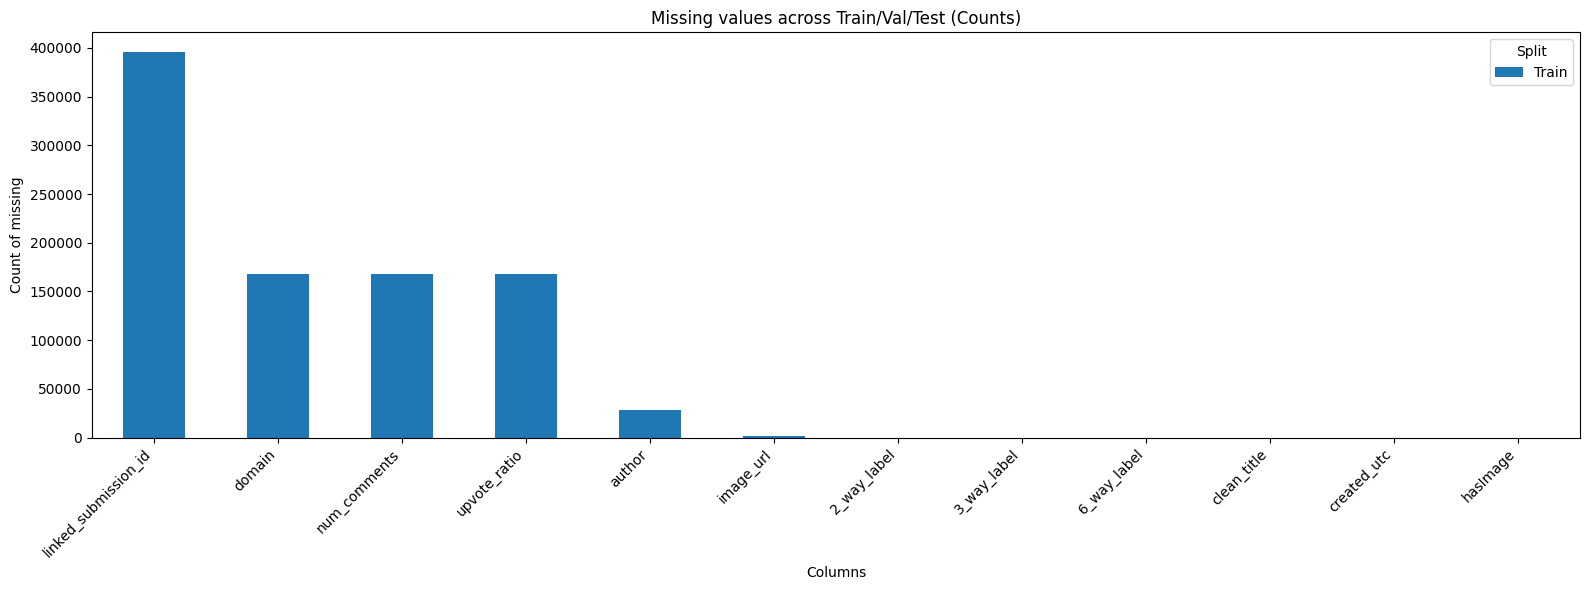


=== Missing Percentages (relative to dataset size) ===
                      Train
linked_submission_id  70.24
domain                29.76
num_comments          29.76
upvote_ratio          29.76
author                 5.09
image_url              0.27
2_way_label            0.00
3_way_label            0.00
6_way_label            0.00
clean_title            0.00
created_utc            0.00
hasImage               0.00


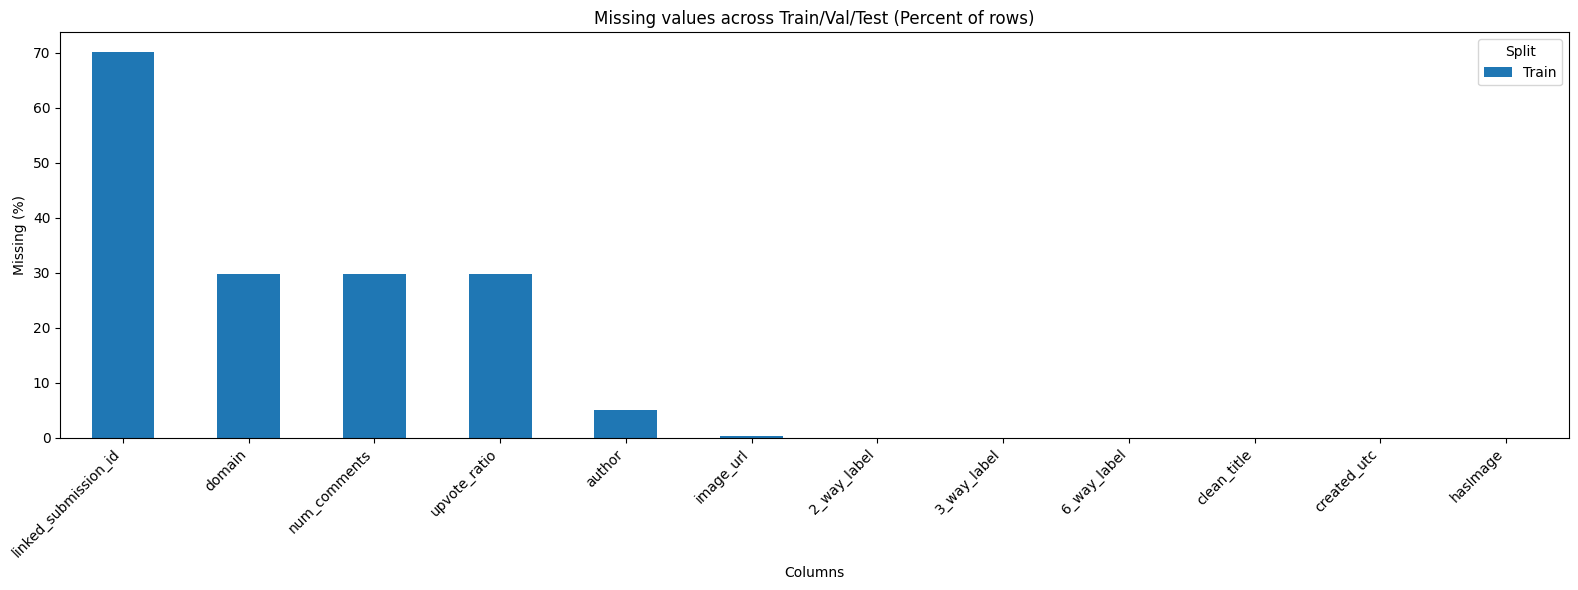

In [67]:
counts, normed = plot_missingness_multi(
    {"Train": train_df},
    treat_empty=True,
    top_n=12,
    title="Missing values across Train/Val/Test"
)

## Label distribution & imbalance across splits

In [54]:
def plot_label_distribution(df_dict, label_cols=["2_way_label","3_way_label","6_way_label"], top_n=None):
    for label_col in label_cols:
        print(f"\n=== Label distribution for {label_col} ===")

        # collect distributions
        dist_table = pd.DataFrame()
        for name, df in df_dict.items():
            if label_col not in df.columns:
                continue
            vc = df[label_col].value_counts(dropna=False).sort_index()
            if top_n:
                vc = vc.head(top_n)
            dist_table[name] = vc

        # add percentages
        pct_table = dist_table.div(dist_table.sum(axis=0), axis=1) * 100

        ############################### print counts
        print("\n===> Counts:")
        print(dist_table.fillna(0).astype(int))
        print("\n===> Percentages:")
        print(pct_table.round(2))

        ############################### plot
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # absolute counts
        dist_table.plot(kind="bar", ax=axes[0])
        axes[0].set_title(f"{label_col} - Counts")
        axes[0].set_xlabel("Class label")
        axes[0].set_ylabel("Count")

        # percentages
        pct_table.plot(kind="bar", ax=axes[1])
        axes[1].set_title(f"{label_col} - Percentages")
        axes[1].set_xlabel("Class label")
        axes[1].set_ylabel("Percentage (%)")

        plt.tight_layout()
        plt.show()


=== Label distribution for 2_way_label ===

===> Counts:
              Train
2_way_label        
0            341919
1            222081

===> Percentages:
             Train
2_way_label       
0            60.62
1            39.38


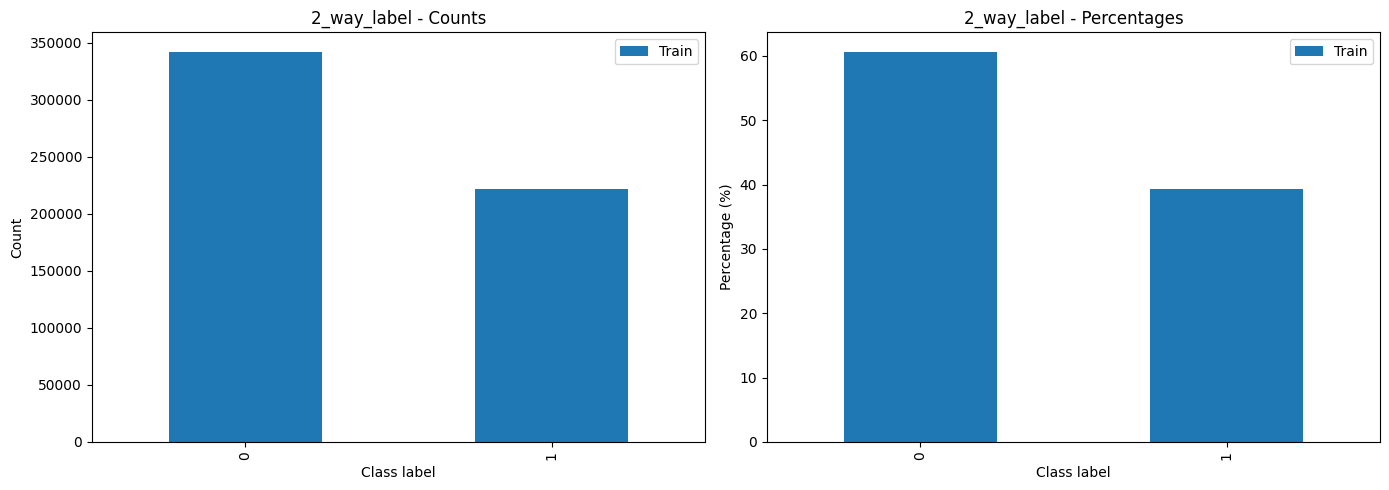


=== Label distribution for 3_way_label ===

===> Counts:
              Train
3_way_label        
0            222081
1             13848
2            328071

===> Percentages:
             Train
3_way_label       
0            39.38
1             2.46
2            58.17


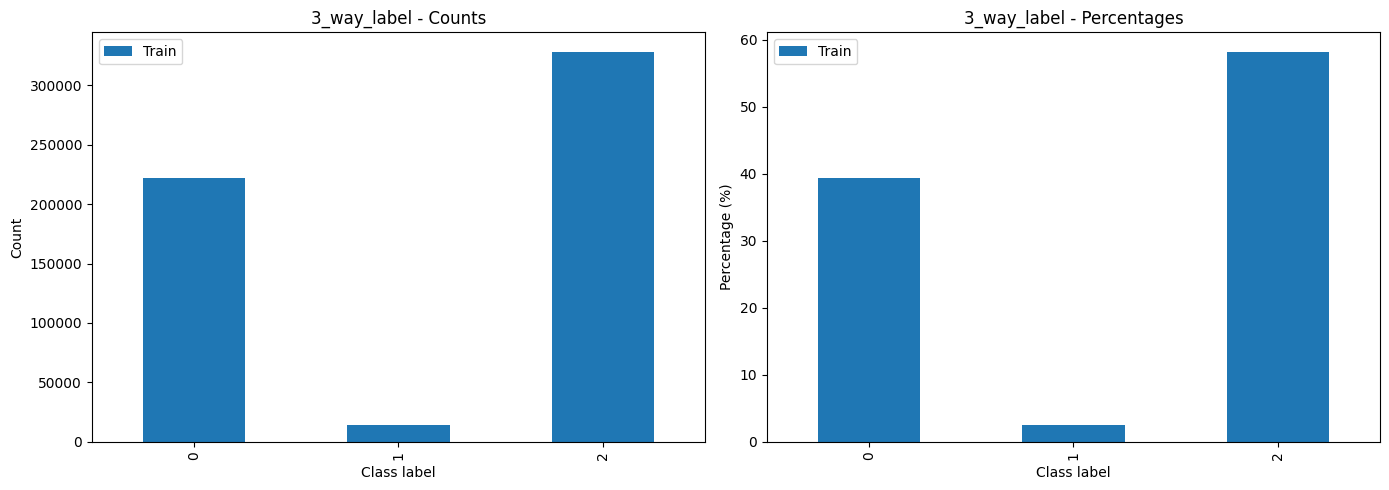


=== Label distribution for 6_way_label ===

===> Counts:
              Train
6_way_label        
0            222081
1             33481
2            107221
3             11784
4            167857
5             21576

===> Percentages:
             Train
6_way_label       
0            39.38
1             5.94
2            19.01
3             2.09
4            29.76
5             3.83


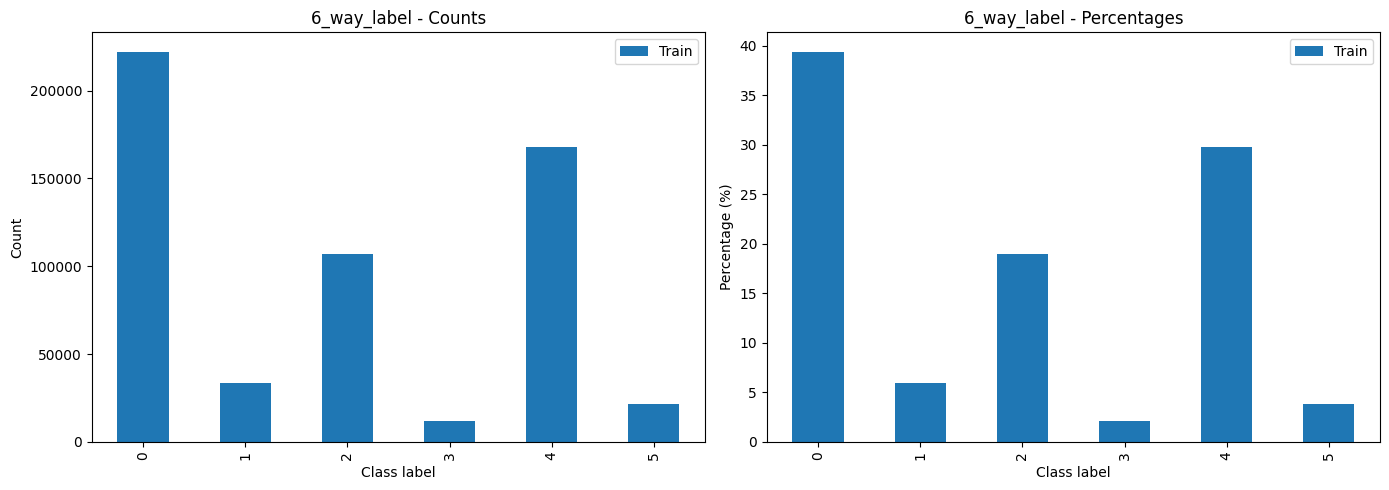

In [55]:
plot_label_distribution(
    {"Train": train_df},
    label_cols=["2_way_label","3_way_label","6_way_label"]
)

## Text characteristics analysis

In [64]:
def plot_title_length_vs_labels_train(train_df,text_col="title",label_cols=("2_way_label","3_way_label","6_way_label"),clip_quantile=0.99,bins=50,use_violin=True):
    
    ############################### Pre-compute lengths once
    df = train_df.copy()
    df["_len"] = df[text_col].fillna("").astype(str).str.len()

    ############################### Loop over each label column
    for label_col in label_cols:
        if label_col not in df.columns:
            continue

        ############################### Create a plotting copy with clipped lengths
        q = df["_len"].quantile(clip_quantile)
        plot_df = df[[label_col, "_len"]].dropna().copy()
        plot_df["_len_clip"] = np.minimum(plot_df["_len"], q)

        ############################### Print a small, useful summary table
        summary = plot_df.groupby(label_col)["_len"].agg(
            n="count", mean="mean", std="std", p50="median",
            p90=lambda s: s.quantile(0.90)
        ).round(2)
        print(f"\n=== {text_col} length vs {label_col} (TRAIN) ===")
        print(summary)

        ############################### Make two simple plots (side-by-side)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

        
        # ---- LEFT: violin/box plot (shows median + spread clearly)
        groups = [g["_len_clip"].values for _, g in plot_df.groupby(label_col)]
        labels = [str(k) for k in plot_df[label_col].unique()]

        if use_violin:
            axes[0].violinplot(groups, showmeans=True, showmedians=True, showextrema=True)
            axes[0].set_title(f"{text_col} length by {label_col} (violin, clipped @{int(clip_quantile*100)}%)")
        else:
            axes[0].boxplot(groups, showmeans=True)
            axes[0].set_title(f"{text_col} length by {label_col} (box, clipped @{int(clip_quantile*100)}%)")

        axes[0].set_xticks(range(1, len(labels)+1))
        axes[0].set_xticklabels(labels)
        axes[0].set_ylabel("characters (clipped)")

        # ---- RIGHT: normalized histograms (density=1 per label → shape comparison)
        for lab, g in plot_df.groupby(label_col):
            axes[1].hist(g["_len_clip"], bins=bins, density=True, alpha=0.4, label=f"{label_col}={lab}")
        axes[1].set_title(f"{text_col} length density by {label_col}")
        axes[1].set_xlabel("characters (clipped)")
        axes[1].set_ylabel("density")
        axes[1].legend(title="Label")

        plt.show()

    ############################### Cleanup
    df.drop(columns=["_len"], inplace=True, errors="ignore")


=== title length vs 2_way_label (TRAIN) ===
                  n   mean    std   p50   p90
2_way_label                                  
0            341919  38.95  35.82  28.0  83.0
1            222081  57.42  31.99  52.0  90.0


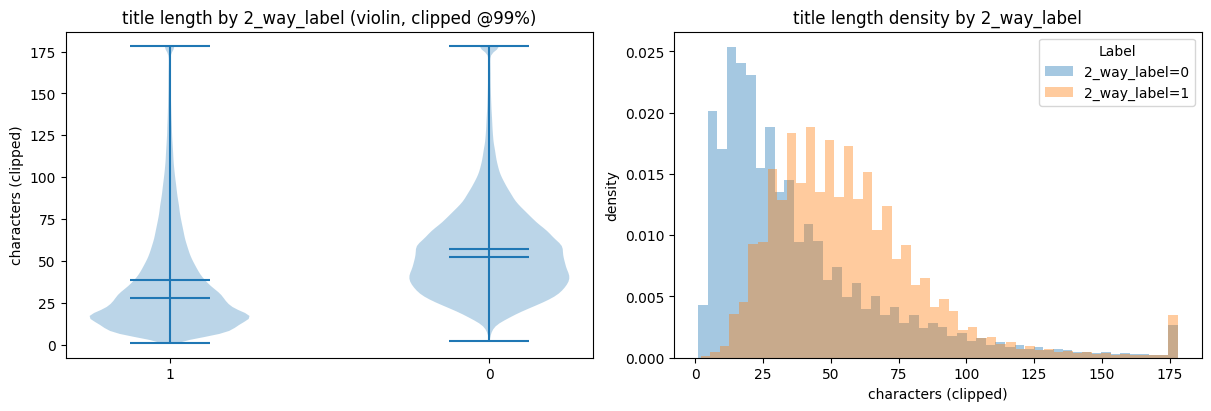


=== title length vs 3_way_label (TRAIN) ===
                  n   mean    std   p50    p90
3_way_label                                   
0            222081  57.42  31.99  52.0   90.0
1             13848  79.65  45.62  69.0  138.3
2            328071  37.23  34.30  27.0   79.0


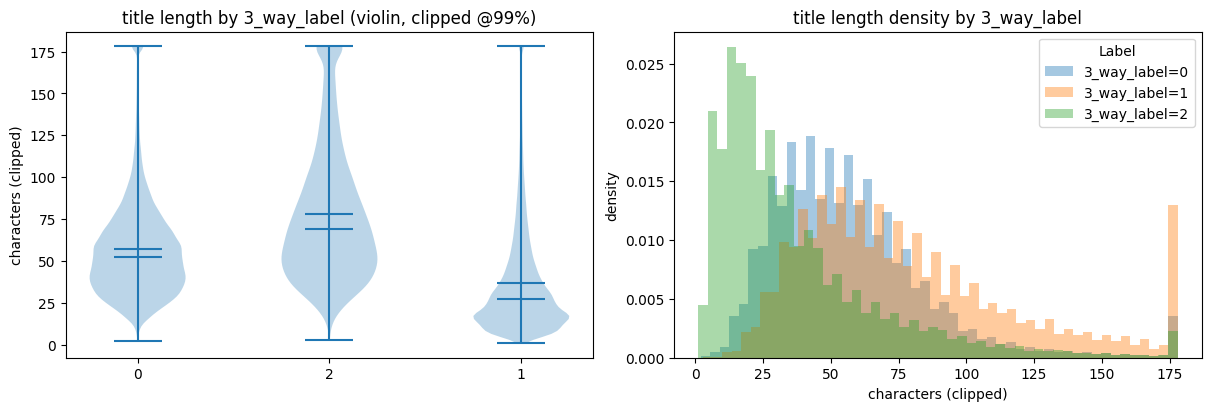


=== title length vs 6_way_label (TRAIN) ===
                  n   mean    std   p50    p90
6_way_label                                   
0            222081  57.42  31.99  52.0   90.0
1             33481  48.07  32.14  37.0   92.0
2            107221  45.44  30.27  39.0   84.0
3             11784  80.37  36.96  75.0  127.0
4            167857  22.33  20.36  17.0   42.0
5             21576  99.27  56.03  87.0  177.0


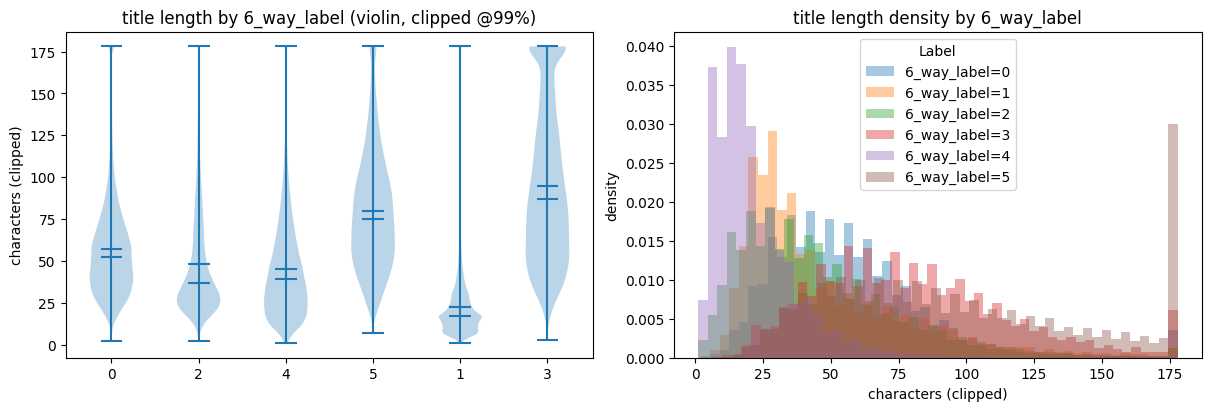

In [65]:
############################### Run: title length vs labels on TRAIN
plot_title_length_vs_labels_train(
    train_df,
    text_col="title",
    label_cols=("2_way_label","3_way_label","6_way_label"),
    clip_quantile=0.99,
    bins=50,
    use_violin=True
)

## Image Properties

In [87]:
############################### helpers
def _safe_get(url, timeout=10):
    try:
        with request.urlopen(url, timeout=timeout) as r:
            b = r.read()
            if b and len(b) >= 100:  # skip empty/tiny
                return b
    except:
        pass
    return None

def _probe(b):
    try:
        im = Image.open(io.BytesIO(b)).convert("RGB")
        w, h = im.size
        arr = np.asarray(im, dtype=np.uint8)
        gray = (0.299*arr[...,0] + 0.587*arr[...,1] + 0.114*arr[...,2]).astype(np.float32)
        brightness = float(gray.mean())
        gx = np.abs(np.diff(gray, axis=1)).mean()
        gy = np.abs(np.diff(gray, axis=0)).mean()
        complexity = float((gx + gy) / 2.0)
        mpix = (w*h) / 1e6
        return dict(mpix=mpix, brightness=brightness, complexity=complexity)
    except:
        return None

############################### main (one label at a time)
def analyze_images_by_label_simple(train_df, label_col="2_way_label",
                                   sample_n=300, timeout=10, clip_q=0.99):
    ############################### pick deterministic top-N with valid URLs
    has_img = (train_df["hasImage"]) & (train_df["image_url"].astype(str).str.strip() != "")
    rows = train_df.loc[has_img, ["id", "image_url", label_col]].head(sample_n)

    ############################### download + probe
    recs = []
    for _, r in rows.iterrows():
        b = _safe_get(r["image_url"], timeout=timeout)
        if b is None: 
            continue
        p = _probe(b)
        if p is None: 
            continue
        p[label_col] = r[label_col]
        recs.append(p)

    if not recs:
        print("No images could be analyzed.")
        return pd.DataFrame()

    dfm = pd.DataFrame(recs)

    ############################### clip outliers for plotting only
    plot_df = dfm.copy()
    for col in ["mpix","brightness","complexity"]:
        q = plot_df[col].quantile(clip_q)
        plot_df[col] = np.minimum(plot_df[col], q)

    ############################### tiny summary (n, mean, median) per class
    summary = dfm.groupby(label_col)[["mpix","brightness","complexity"]].agg(
        n=("mpix","count"),
        mpix_mean=("mpix","mean"), mpix_med=("mpix","median"),
        bright_mean=("brightness","mean"), bright_med=("brightness","median"),
        comp_mean=("complexity","mean"), comp_med=("complexity","median"),
    ).round(2)
    print(f"\n=== Image properties by {label_col} (train, n up to {sample_n}) ===")
    print(summary)

    ############################### 3 boxplots (easy to compare)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

    # mpix
    data = [g["mpix"].values for _, g in plot_df.groupby(label_col)]
    labels = [str(l) for l in plot_df[label_col].unique()]
    axes[0].boxplot(data, showmeans=True)
    axes[0].set_title("Size (megapixels)")
    axes[0].set_xticks(range(1, len(labels)+1)); axes[0].set_xticklabels(labels)
    axes[0].grid(True, alpha=0.3)

    # brightness
    data = [g["brightness"].values for _, g in plot_df.groupby(label_col)]
    axes[1].boxplot(data, showmeans=True)
    axes[1].set_title("Brightness (0–255)")
    axes[1].set_xticks(range(1, len(labels)+1)); axes[1].set_xticklabels(labels)
    axes[1].grid(True, alpha=0.3)

    # complexity
    data = [g["complexity"].values for _, g in plot_df.groupby(label_col)]
    axes[2].boxplot(data, showmeans=True)
    axes[2].set_title("Complexity (avg |grad|)")
    axes[2].set_xticks(range(1, len(labels)+1)); axes[2].set_xticklabels(labels)
    axes[2].grid(True, alpha=0.3)

    fig.suptitle(f"Image properties by {label_col} (clipped @{int(clip_q*100)}%)",fontsize=12, y=1.05)
    plt.show()

    return dfm


=== Image properties by 2_way_label (train, n up to 500) ===
               n  mpix_mean  mpix_med  bright_mean  bright_med  comp_mean  \
2_way_label                                                                 
0            136        0.1      0.10       118.50      117.76       7.73   
1            197        0.1      0.08       110.07      110.05       7.19   

             comp_med  
2_way_label            
0                6.76  
1                6.58  


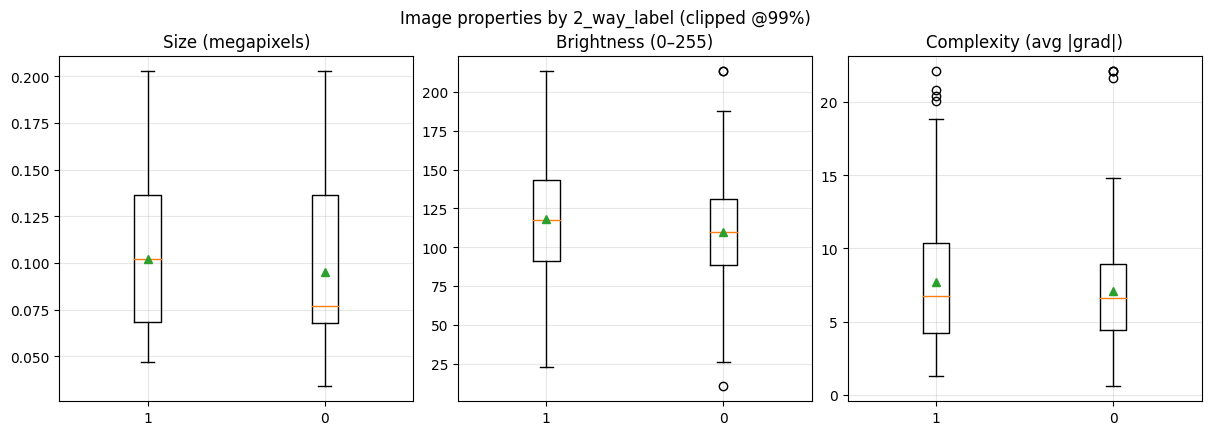


=== Image properties by 3_way_label (train, n up to 500) ===
               n  mpix_mean  mpix_med  bright_mean  bright_med  comp_mean  \
3_way_label                                                                 
0            197       0.10      0.08       110.07      110.05       7.19   
1             16       0.12      0.14       130.81      139.04       9.84   
2            120       0.10      0.10       116.86      114.25       7.45   

             comp_med  
3_way_label            
0                6.58  
1                8.86  
2                6.61  


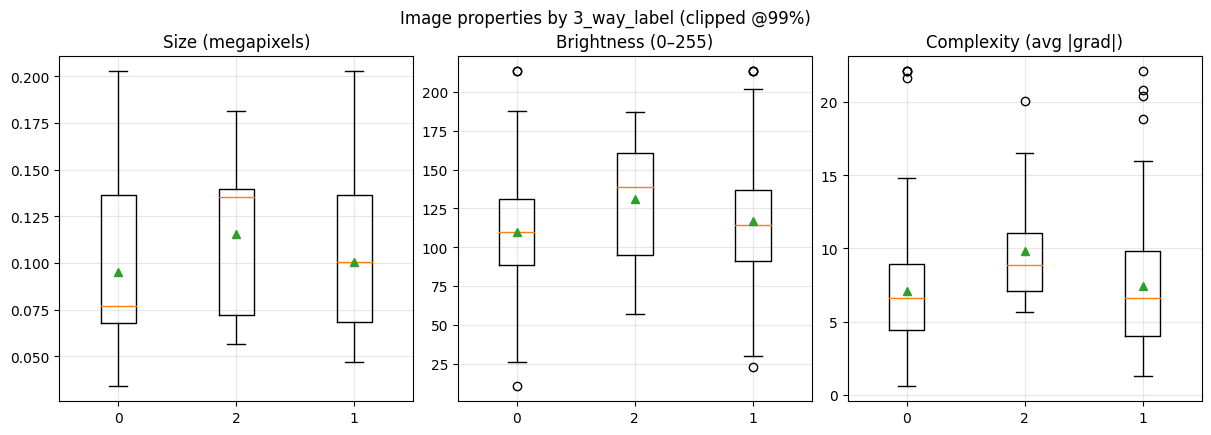


=== Image properties by 6_way_label (train, n up to 500) ===
               n  mpix_mean  mpix_med  bright_mean  bright_med  comp_mean  \
6_way_label                                                                 
0            197       0.10      0.08       110.07      110.05       7.19   
1             21       0.09      0.10       117.47      106.19       7.59   
2             86       0.10      0.10       118.25      115.98       7.31   
3              9       0.10      0.07       103.22       99.35       8.31   
5             20       0.11      0.10       127.55      133.42       9.44   

             comp_med  
6_way_label            
0                6.58  
1                5.93  
2                6.53  
3                7.41  
5                8.31  


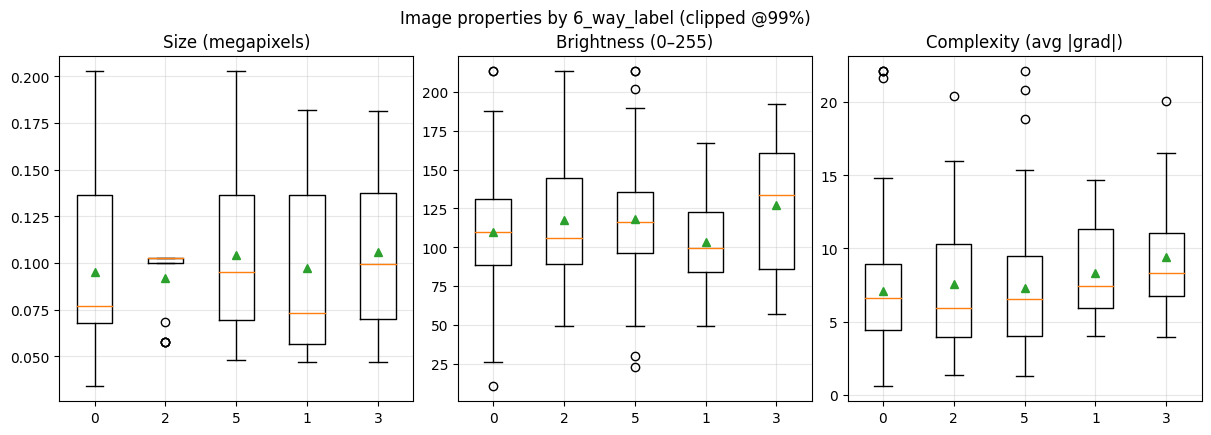

In [88]:
############################### 2-way (real vs fake)
img2 = analyze_images_by_label_simple(train_df, label_col="2_way_label", sample_n=500)

############################### 3-way
img3 = analyze_images_by_label_simple(train_df, label_col="3_way_label", sample_n=500)

############################### 6-way
img6 = analyze_images_by_label_simple(train_df, label_col="6_way_label", sample_n=500)

## Domains by class

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import re

def _domain_of(url):
    try:
        s = re.sub(r"^https?://", "", str(url)).split("/")[0].lower()
        return re.sub(r"^www\.", "", s)
    except:
        return ""

def plot_image_domains_by_label(train_df, label_col="2_way_label", top_n=10):
    ############################### filter rows with valid images
    if label_col not in train_df.columns:
        print(f"{label_col} not in dataframe.")
        return

    has_img = (train_df["hasImage"]) & (train_df["image_url"].astype(str).str.strip() != "")
    df = train_df.loc[has_img, ["image_url", label_col]].copy()
    if df.empty:
        print("No rows with images.")
        return

    ############################### extract domain & keep top-N by frequency
    df["domain"] = df["image_url"].apply(_domain_of)
    top_domains = df["domain"].value_counts().head(top_n).index.tolist()
    df = df[df["domain"].isin(top_domains)]

    ############################### crosstab and sort by TOTAL count
    tbl = pd.crosstab(df["domain"], df[label_col])
    tbl["__total__"] = tbl.sum(axis=1)
    tbl = tbl.sort_values("__total__", ascending=False).drop(columns="__total__")

    ############################### print counts
    print("\n=== Top image domains by label (counts) ===")
    print(tbl)

    ############################### plot row-normalized fractions
    frac = tbl.div(tbl.sum(axis=1), axis=0)  # each domain sums to 1
    ax = frac.plot(kind="bar", figsize=(12, 6))
    ax.set_title(f"Top {top_n} image domains by {label_col} (row fractions)")
    ax.set_xlabel("domain")
    ax.set_ylabel("fraction")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


=== Top image domains by label (counts) ===
2_way_label                        0       1
domain                                      
external-preview.redd.it       89938  129293
preview.redd.it                83665   91713
i.imgur.com                   160318       0
imgur.com                       2889       0
nan                              459    1075
i.redd.it                       1285       0
upload.wikimedia.org             130       0
i.postimg.cc                      80       0
i.dailymail.co.uk                 60       0
s-media-cache-ak0.pinimg.com      58       0


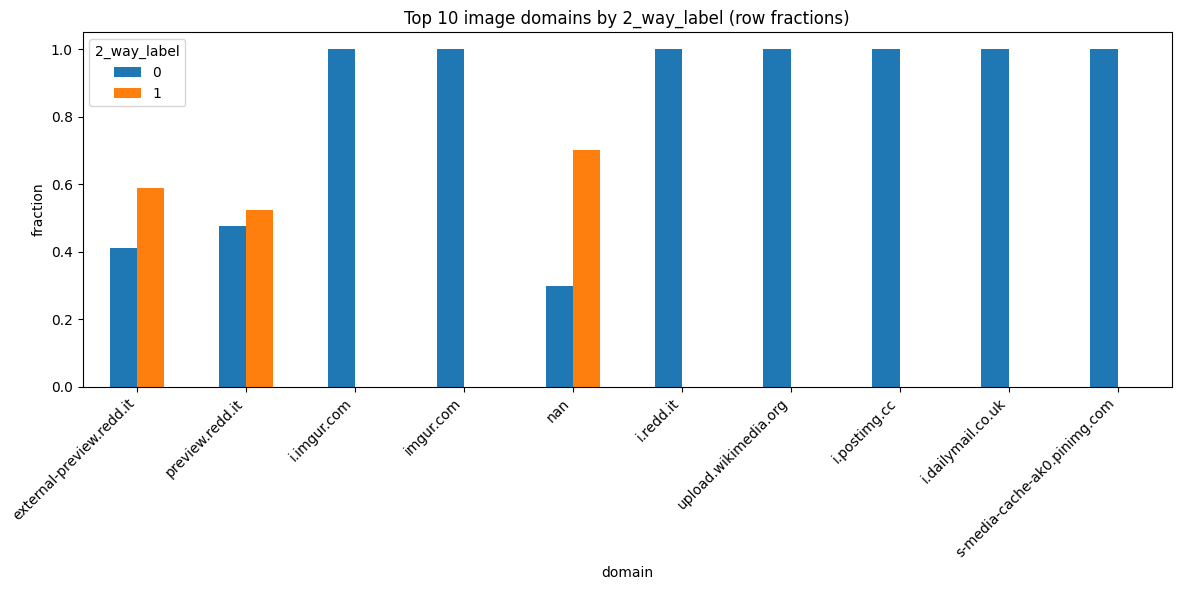


=== Top image domains by label (counts) ===
3_way_label                        0     1       2
domain                                            
external-preview.redd.it      129293  8454   81484
preview.redd.it                91713  5374   78291
i.imgur.com                        0     0  160318
imgur.com                          0     0    2889
nan                             1075    20     439
i.redd.it                          0     0    1285
upload.wikimedia.org               0     0     130
i.postimg.cc                       0     0      80
i.dailymail.co.uk                  0     0      60
s-media-cache-ak0.pinimg.com       0     0      58


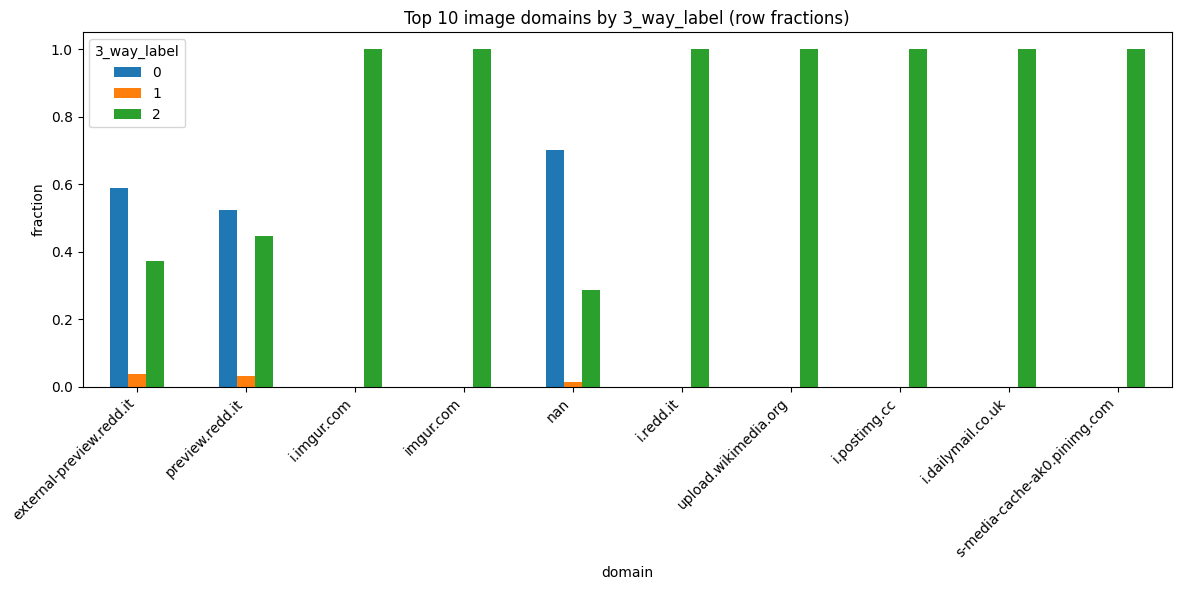


=== Top image domains by label (counts) ===
6_way_label                        0      1      2     3       4      5
domain                                                                 
external-preview.redd.it      129293  17380  47158  9341       0  16059
preview.redd.it                91713  16026  59722  2434       0   5483
i.imgur.com                        0      0      0     0  160318      0
imgur.com                          0      0      0     0    2889      0
nan                             1075     75    341     9       0     34
i.redd.it                          0      0      0     0    1285      0
upload.wikimedia.org               0      0      0     0     130      0
i.postimg.cc                       0      0      0     0      80      0
i.dailymail.co.uk                  0      0      0     0      60      0
s-media-cache-ak0.pinimg.com       0      0      0     0      58      0


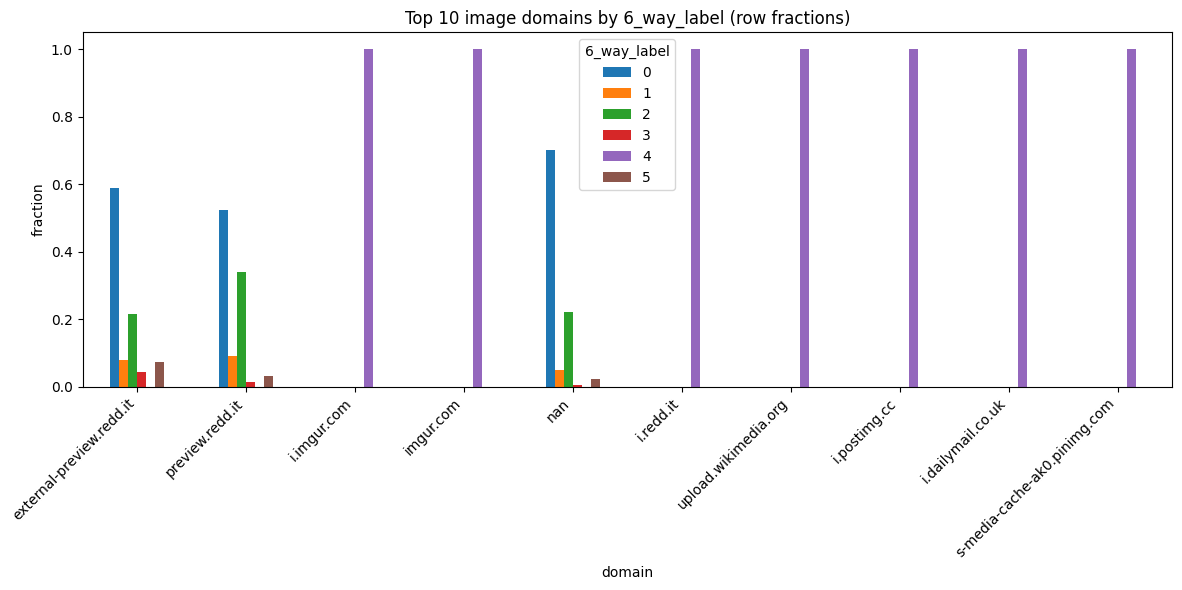

In [95]:
plot_image_domains_by_label(train_df, label_col="2_way_label", top_n=10)
plot_image_domains_by_label(train_df, label_col="3_way_label", top_n=10)
plot_image_domains_by_label(train_df, label_col="6_way_label", top_n=10)

## Downloading Images and Creating sub-datasets

In [32]:
def create_subcsv_and_download(df, base_dir, csv_name="train_subset.csv", img_folder="train_images", limit=10):
    # clean
    df = df.replace(np.nan, '', regex=True)
    df.fillna('', inplace=True)

    ############################### paths
    img_dir = os.path.join(base_dir, img_folder)
    os.makedirs(img_dir, exist_ok=True)

    picked = []
    count = 0

    ############################### progress bar setup
    if limit == -1:
        iterator = tqdm(df.iterrows(), total=len(df), desc="Downloading images", unit="row")
    else:
        iterator = df.iterrows()
        pbar = trange(limit, desc="Downloading images", unit="img")

    for _, row in iterator:
        if limit != -1 and count >= limit:
            break

        if row["hasImage"] == True and row["image_url"] not in ["", "nan"]:
            url = row["image_url"]
            final_path = os.path.join(img_dir, f"{row['id']}.jpg")
            tmp_path = final_path + ".tmp"

            try:
                data = request.urlopen(url, timeout=12).read()
                if not data or len(data) < 100:
                    continue

                with open(tmp_path, "wb") as f:
                    f.write(data)
                os.replace(tmp_path, final_path)

                picked.append(row)
                if limit != -1:
                    count += 1
                    pbar.update(1)

            except:
                if os.path.exists(tmp_path):
                    os.remove(tmp_path)
                continue

    if limit != -1:
        pbar.close()

    ############################### save CSV of successfully downloaded rows
    out_csv = os.path.join(base_dir, csv_name)
    pd.DataFrame(picked).to_csv(out_csv, index=False)
    print(f"\nCreated {out_csv} with {len(picked)} rows")
    print(f"Images saved in {img_dir}")

In [33]:
############################### Train Sub dataset
create_subcsv_and_download(
    df=train_df,
    base_dir=str(BASE_DATA_DIR),
    csv_name="train_subset.csv",
    img_folder="train_images",
    limit=1000
)

############################### Valid Sub dataset
create_subcsv_and_download(
    df=val_df,
    base_dir=str(BASE_DATA_DIR),
    csv_name="valid_subset.csv",
    img_folder="valid_images",
    limit=100
)

############################### Test Sub dataset
create_subcsv_and_download(
    df=test_df,
    base_dir=str(BASE_DATA_DIR),
    csv_name="test_subset.csv",
    img_folder="test_images",
    limit=100
)


Created ../../project_dataset/fakeddit_data/multimodal_only_samples/train_subset.csv with 1000 rows
Images saved in ../../project_dataset/fakeddit_data/multimodal_only_samples/train_images



Created ../../project_dataset/fakeddit_data/multimodal_only_samples/valid_subset.csv with 100 rows
Images saved in ../../project_dataset/fakeddit_data/multimodal_only_samples/valid_images



Created ../../project_dataset/fakeddit_data/multimodal_only_samples/test_subset.csv with 100 rows
Images saved in ../../project_dataset/fakeddit_data/multimodal_only_samples/test_images
